In [1]:
# Import the python packages. Rerun this code again if there is you encounter an error on xarray_schema.
import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
import spatialdata_plot
import seaborn as sns

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\scanpy\_utils\__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\scanpy\readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning`

In [3]:
# Define paths for raw xenium data and Zarr store
xenium_path = "E:/DATA_3/CTNND2/Omics/20250822_xenium/data/20250912_165800_250912_Eroglu_0064/output-XETG00345__0069945__1M__20250912__165818/outs"
zarr_path = "E:/DATA_3/CTNND2/Omics/20250822_xenium/data/20250912_165800_250912_Eroglu_0064/output-XETG00345__0069945__1M__20250912__165818/Xenium_1M_WT.zarr"

In [ ]:
## Skip if zarr is already generated and instead just read in from Zarr store (next cell)
sdata = sio.xenium(xenium_path, morphology_focus=False)
## We delete the image as it takes up a lot of memory and we do not use for this analysis guide
sdata.write(zarr_path)

In [4]:
sdata = sd.read_zarr(zarr_path)
sdata

SpatialData object, with associated Zarr store: E:\DATA_3\CTNND2\Omics\20250822_xenium\data\20250912_165800_250912_Eroglu_0064\output-XETG00345__0069945__1M__20250912__165818\Xenium_1M_WT.zarr
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34305, 51138), (17152, 25569), (8576, 12784), (4288, 6392), (2144, 3196)
│     └── 'nucleus_labels': DataTree[yx] (34305, 51138), (17152, 25569), (8576, 12784), (4288, 6392), (2144, 3196)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (120876, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (120876, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (119697, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (120876, 346)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries 

## Subset visual cortex

In [15]:
select_cells = pd.read_csv(
    "E:/DATA_3/CTNND2/Omics/20250822_xenium/data/20250912_165800_250912_Eroglu_0064/output-XETG00345__0069945__1M__20250912__165818/1M_VC_subset_cells_stats.csv", skiprows=2
)
select_cells.head()

,Cell ID,Cluster,Transcripts,Area (µm^2)
0,mljpmddo-1,Cluster 10,0,167.03
1,mhpnjhad-1,Cluster 2,0,61.59
2,mfokkhlj-1,Cluster 8,0,61.95
3,mgckhneh-1,Cluster 2,0,111.27
4,bjhocpki-1,Cluster 10,0,197.51


In [16]:
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

subset_sdata = sd.match_sdata_to_table(
    sdata,
    table=sdata["table"][sdata["table"].obs["cell_id"].isin(select_cells["Cell ID"])],
    table_name="table",
    how="right",
)

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


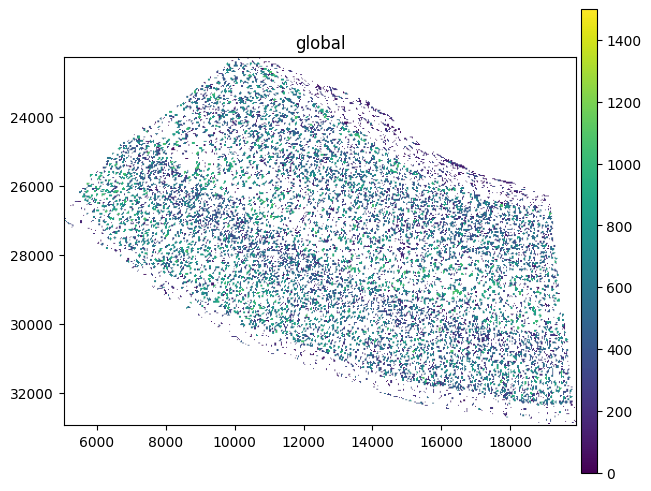

In [17]:
# Clipping the data for the plotting to be more obvious.
import matplotlib.colors as mpc

norm = mpc.Normalize(vmin=0, vmax=1500, clip=True)

subset_sdata.pl.render_shapes(
    "cell_boundaries", color="total_counts", norm=norm
).pl.show()


## Quality control

In [20]:
# Convert sdata object to anndata object (spatial coordinates become obsm)
# Print obs and obsm to check that table was generated correctly

subset_adata = subset_sdata.tables["table"]
subset_adata

AnnData object with n_obs × n_vars = 10133 × 344
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [21]:
sc.pp.calculate_qc_metrics(subset_adata, percent_top=(10, 20, 50, 150), inplace=True)

<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

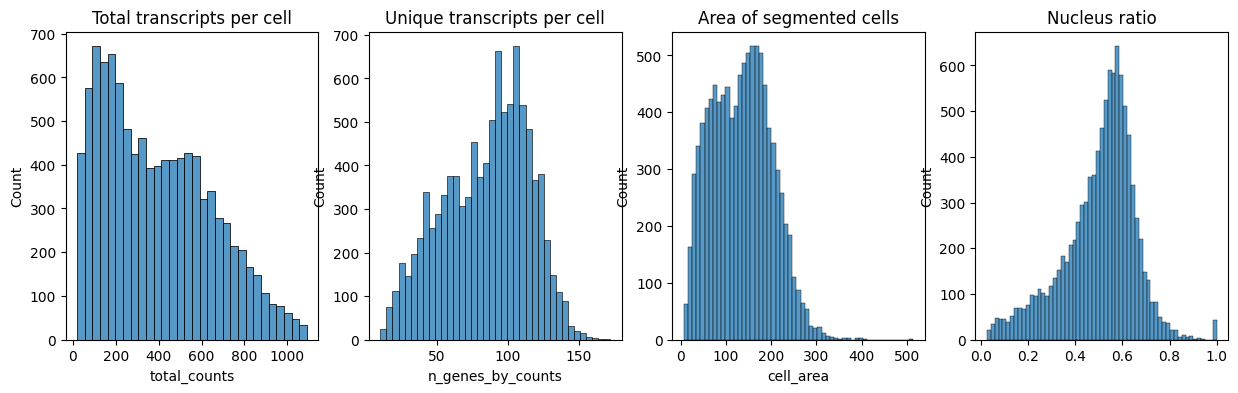

In [22]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    subset_adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    subset_adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    subset_adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    subset_adata.obs["nucleus_area"] / subset_adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

Text(0, 0.5, 'Number of cells')

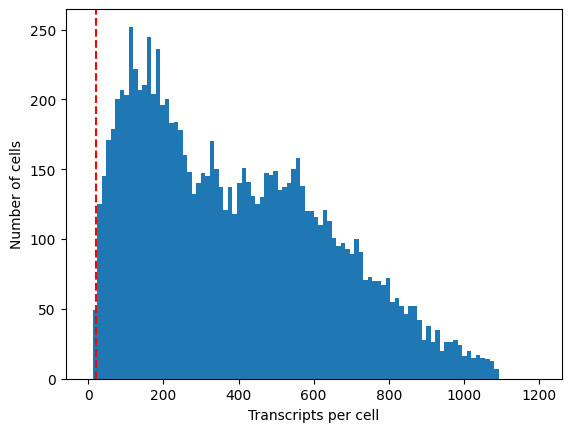

In [23]:
fig = plt.hist(subset_adata.obs["total_counts"], range=(0, 1200), bins=100)
plt.axvline(x=20, color="r", linestyle="--")  # You can customize color and linestyle

plt.xlabel("Transcripts per cell")
plt.ylabel("Number of cells")

In [24]:
# Based on the histogram plot, here we choose 20 transcript counts as lower cutoff
thres = np.quantile(subset_adata.obs["total_counts"], 0.98)
sc.pp.filter_cells(subset_adata, min_counts=20)
sc.pp.filter_cells(subset_adata, max_counts=thres)

# We also filter out genes that are rarely expressed
sc.pp.filter_genes(subset_adata, min_cells=100)

## Initial normalization and clustering

In [ ]:
subset_adata.layers["counts"] = subset_adata.X.copy()

In [ ]:
sc.pp.normalize_total(subset_adata, inplace=True)
sc.pp.log1p(subset_adata)
sc.pp.pca(subset_adata)
sc.pp.neighbors(subset_adata)
sc.tl.umap(subset_adata)

In [ ]:
import leidenalg
sc.tl.leiden(subset_adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(subset_adata, key_added='leiden_res0_1', resolution=0.1)
sc.tl.leiden(subset_adata, key_added='leiden_res0_5', resolution=0.5)
sc.tl.leiden(subset_adata, key_added='leiden_res0_75', resolution=0.75)

In [ ]:
subset_adata.write_h5ad(filename = "E:/DATA_3/CTNND2/Omics/20250822_xenium/data/20250912_165800_250912_Eroglu_0064/output-XETG00345__0069945__1M__20250912__165818/1M_KO_VC_subset.h5ad")

In [ ]:
subset_adata = sc.read_h5ad("E:/DATA_3/CTNND2/Omics/20250822_xenium/data/20250912_165800_250912_Eroglu_0064/output-XETG00345__0069945__1M__20250912__165818/1M_KO_VC_subset.h5ad")